In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("../DATA/PROCESS")
OUTPUT_DIR = Path("../RESULT")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_PATH = BASE_DIR / "facility_location_best_selected_j.csv"
RAW_PATH = BASE_DIR / "save_dataset3.csv"

OUTPUT_PATH = OUTPUT_DIR / "final_selected_j_analysis_dataset.csv"

selected = pd.read_csv(SELECTED_PATH)
raw = pd.read_csv(RAW_PATH)

selected["original_index"] = selected["original_index"].astype(int)

raw_with_index = raw.reset_index().rename(columns={"index": "original_index"})

drop_cols_from_selected = [
    col for col in raw_with_index.columns
    if col in selected.columns and col != "original_index"
]

raw_for_merge = raw_with_index.drop(columns=drop_cols_from_selected)

final_analysis_df = selected.merge(
    raw_for_merge,
    on="original_index",
    how="left",
    validate="one_to_one"
)

front_cols = [
    "selection_order",
    "j_index",
    "original_index",
    "datetime",
    "자치구코드",
    "위도",
    "경도",
    "hour",
    "weekday",
    "month",
    "요일",
    "시간대",
    "시간대그룹",
    "target",
    "covered_h_count",
    "pair_count",
    "avg_x_sim",
    "avg_c_sim_scaled",
    "avg_rank",
    "avg_time_diff",
    "nearest_local_dist_m",
    "nearest_local_기수",
    "nearest_local_선정연도",
    "nearest_local_자치구",
    "nearest_local_상권명",
    "nearest_local_대표 주소/위치",
    "nearest_local_매칭_상권_구분",
    "nearest_local_매칭_상권명",
    "nearest_local_매칭_행정동",
]

front_cols = [c for c in front_cols if c in final_analysis_df.columns]
other_cols = [c for c in final_analysis_df.columns if c not in front_cols]

final_analysis_df = final_analysis_df[front_cols + other_cols]

final_analysis_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("저장 완료:", OUTPUT_PATH)
print("shape:", final_analysis_df.shape)
final_analysis_df.head()

저장 완료: ../RESULT/final_selected_j_analysis_dataset.csv
shape: (21, 146)


,selection_order,j_index,original_index,datetime,자치구코드,위도,경도,hour,weekday,month,...,subway_cnt_300m_y,subway_cnt_500m_y,subway_cnt_1000m_y,subway_cnt_1500m_y,nearest_subway_dist_m_y,nearest_subway_line_y,subway_weighted_access_k5_y,subway_mean_dist_k5_m_y,subway_line_cnt_1000m,subway_line_entropy_1000m
0,1,222819,3447541,2025-12-06 13:40:00,11110.0,37.582331,126.983559,13,5,12,...,0,0,1,6,671.781587,3호선,0.004654,1148.035184,1,-1.000000e-09
1,2,94626,1305740,2025-11-02 10:06:00,11305.0,37.630376,127.022628,10,6,11,...,0,0,4,7,507.042957,4호선,0.007487,718.889292,2,6.931472e-01
2,3,163172,2408836,2024-12-30 08:30:00,11140.0,37.563846,126.981866,8,0,12,...,1,2,9,23,249.998392,2호선,0.011319,493.608395,5,1.522955e+00
3,4,47653,642592,2025-07-03 03:09:00,11320.0,37.640683,127.035490,3,3,7,...,0,0,2,3,885.962134,4호선,0.004096,1326.339690,1,-1.000000e-09
4,5,69813,967412,2024-12-30 05:01:00,11320.0,37.637817,127.038271,5,0,12,...,0,0,0,3,1104.410897,4호선,0.003572,1449.675195,0,0.000000e+00


In [2]:
for col in final_analysis_df.columns:
    print(col)

selection_order
j_index
original_index
datetime
자치구코드
위도
경도
hour
weekday
month
요일
시간대
시간대그룹
target
covered_h_count
pair_count
avg_x_sim
avg_c_sim_scaled
avg_rank
avg_time_diff
nearest_local_dist_m
nearest_local_기수
nearest_local_선정연도
nearest_local_자치구
nearest_local_상권명
nearest_local_대표 주소/위치
nearest_local_매칭_상권_구분
nearest_local_매칭_상권명
nearest_local_매칭_행정동
X_PC1
X_PC2
X_PC3
X_PC4
X_PC5
X_PC6
X_PC7
X_PC8
X_PC9
X_PC10
X_PC11
X_PC12
X_PC13
X_PC14
X_PC15
X_PC16
C_PC1
C_PC2
nearest_local_idx
nearest_local_매칭_상권_코드
nearest_local_서울시_X좌표
nearest_local_서울시_Y좌표
space_key
space_j_index
Unnamed: 0.1
Unnamed: 0
hour_sin
hour_cos
weekday_sin
weekday_cos
month_sin
month_cos
gu_walk_area
concert_total
concert_public
concert_private
concert_large
concert_mid
concert_small
heritage_total
designated_total
national_treasure
treasure
historic_site
scenic_site
historic_and_scenic_site
natural_monument
folk_cultural_property
intangible_cultural_property
city_designated_total
tangible_cultural_property
city_mo

### **PART1: 21개 전체 특성 분석**

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

BASE_DIR = Path("../DATA/PROCESS")
RESULT_DIR = Path("../RESULT")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

S_PATH = RESULT_DIR / "final_selected_j_analysis_dataset.csv"
RAW_PATH = BASE_DIR / "save_dataset3.csv"

S = pd.read_csv(S_PATH)
raw = pd.read_csv(RAW_PATH)

H = raw[raw["target"] == 1].copy()
J = raw[raw["target"] == 0].copy()

print("S:", S.shape)
print("H:", H.shape)
print("J:", J.shape)

S: (21, 146)
H: (1993504, 101)
J: (2040402, 101)


In [4]:
feature_cols = [
    "gu_walk_area",
    "concert_total",
    "movie_theater_cnt",
    "movie_screen_cnt",
    "movie_seat_cnt",
    "heritage_total",
    "designated_total",
    "city_designated_total",
    "rest_cnt_500m",
    "rest_cnt_1000m",
    "rest_weighted_density_k20",
    "tour_food_cnt_500m",
    "tour_food_cnt_1000m",
    "tour_food_weighted_density_k20",
    "tour_food_ratio_500m",
    "shop_cnt_500m_x",
    "shop_cnt_1000m_x",
    "shop_weighted_density_k20_x",
    "shop_type_cnt_500m_x",
    "shop_type_entropy_500m",
    "shop_store_type_cnt_500m",
    "shop_store_type_entropy_500m",
    "bus_stop_cnt_500m",
    "subway_cnt_1000m_x",
    "subway_cnt_1500m_x",
    "nearest_subway_dist_m_x",
    "subway_weighted_access_k5_x",
    "subway_line_cnt_1000m",
    "subway_line_entropy_1000m"
]

feature_cols = [c for c in feature_cols if c in S.columns and c in H.columns]

S_feature_summary = S[feature_cols].describe().T
S_feature_summary.to_csv(RESULT_DIR / "selected_21_feature_summary.csv", encoding="utf-8-sig")

S_feature_summary

,count,mean,std,min,25%,50%,75%,max
gu_walk_area,21.0,250585.595238,90904.725143,1.309480e+05,2.061654e+05,240650.300000,282318.000000,587769.000000
concert_total,21.0,32.523810,54.469826,1.000000e+00,6.000000e+00,6.000000,29.000000,161.000000
movie_theater_cnt,21.0,4.952381,2.011870,2.000000e+00,3.000000e+00,5.000000,6.000000,8.000000
movie_screen_cnt,21.0,28.285714,11.023352,1.200000e+01,2.100000e+01,32.000000,34.000000,51.000000
movie_seat_cnt,21.0,4191.809524,1692.439382,1.550000e+03,3.052000e+03,4188.000000,5265.000000,7187.000000
heritage_total,21.0,124.523810,177.884125,7.000000e+00,1.600000e+01,33.000000,108.000000,483.000000
designated_total,21.0,64.428571,109.416896,1.000000e+00,2.000000e+00,9.000000,57.000000,403.000000
city_designated_total,21.0,38.523810,57.238640,3.000000e+00,7.000000e+00,21.000000,30.000000,173.000000
rest_cnt_500m,21.0,325.619048,208.314540,4.000000e+00,2.060000e+02,291.000000,387.000000,870.000000
rest_cnt_1000m,21.0,1058.666667,650.698343,1.630000e+02,6.010000e+02,1017.000000,1380.000000,2964.000000


In [39]:
feature_groups = {
    "walkability": [
        "gu_walk_area"
    ],
    "culture": [
        "concert_total",
        "movie_theater_cnt",
        "movie_screen_cnt",
        "movie_seat_cnt"
    ],
    "heritage": [
        "heritage_total",
        "designated_total",
        "city_designated_total",
        "national_registered_cultural_property",
        "city_registered_cultural_property"
    ],
    "restaurant": [
        "rest_cnt_500m",
        "rest_cnt_1000m",
        "nearest_rest_dist_m",
        "rest_weighted_density_k20",
        "rest_mean_dist_k20_m"
    ],
    "tour_food": [
        "tour_food_cnt_500m",
        "tour_food_cnt_1000m",
        "nearest_tour_food_dist_m",
        "tour_food_weighted_density_k20",
        "tour_food_ratio_500m"
    ],
    "shop": [
        "shop_cnt_500m_x",
        "shop_cnt_1000m_x",
        "nearest_shop_dist_m_x",
        "shop_weighted_density_k20_x",
        "shop_type_cnt_500m_x"
    ],
    "diversity": [
        "shop_type_entropy_500m",
        "shop_store_type_cnt_500m",
        "shop_store_type_entropy_500m"
    ],
    "bus": [
        "bus_stop_cnt_100m",
        "bus_stop_cnt_300m",
        "bus_stop_cnt_500m",
        "bus_info_cnt_300m"
    ],
    "subway": [
        "subway_cnt_300m_x",
        "subway_cnt_500m_x",
        "subway_cnt_1000m_x",
        "subway_cnt_1500m_x",
        "nearest_subway_dist_m_x",
        "subway_weighted_access_k5_x",
        "subway_mean_dist_k5_m_x",
        "subway_line_cnt_1000m",
        "subway_line_entropy_1000m"
    ]
}

available_feature_groups = {
    group: [c for c in cols if c in S.columns and c in J.columns]
    for group, cols in feature_groups.items()
}

available_feature_groups = {
    group: cols
    for group, cols in available_feature_groups.items()
    if len(cols) > 0
}

In [40]:
profile_records = []

for group, cols in available_feature_groups.items():
    for col in cols:
        S[col] = pd.to_numeric(S[col], errors="coerce")
        J[col] = pd.to_numeric(J[col], errors="coerce")

        s_mean = S[col].mean()
        j_mean = J[col].mean()
        j_std = J[col].std()

        standardized_profile = (s_mean - j_mean) / j_std if j_std != 0 else np.nan

        profile_records.append({
            "family": group,
            "feature": col,
            "selected_mean": s_mean,
            "non_congested_mean": j_mean,
            "raw_diff_S_minus_J": s_mean - j_mean,
            "standardized_profile_S_minus_J": standardized_profile,
            "abs_standardized_profile": abs(standardized_profile)
        })

profile_all_df = pd.DataFrame(profile_records)

profile_all_df = profile_all_df.sort_values(
    ["family", "abs_standardized_profile"],
    ascending=[True, False]
)

profile_all_df.to_csv(
    RESULT_DIR / "selected_21_all_feature_profile_by_family.csv",
    index=False,
    encoding="utf-8-sig"
)

profile_all_df

,family,feature,selected_mean,non_congested_mean,raw_diff_S_minus_J,standardized_profile_S_minus_J,abs_standardized_profile
30,bus,bus_stop_cnt_500m,18.761905,21.553359,-2.791454,-0.367328,0.367328
28,bus,bus_stop_cnt_100m,1.666667,1.418745,0.247921,0.162858,0.162858
29,bus,bus_stop_cnt_300m,7.761905,8.273745,-0.511840,-0.141083,0.141083
31,bus,bus_info_cnt_300m,0.000000,0.000000,0.000000,NaN,NaN
2,culture,movie_theater_cnt,4.952381,4.239066,0.713315,0.331844,0.331844
1,culture,concert_total,32.523810,22.166158,10.357651,0.251277,0.251277
4,culture,movie_seat_cnt,4191.809524,3780.054987,411.754537,0.229030,0.229030
3,culture,movie_screen_cnt,28.285714,25.604203,2.681512,0.227634,0.227634
25,diversity,shop_type_entropy_500m,0.360497,0.232522,0.127976,0.355167,0.355167
27,diversity,shop_store_type_entropy_500m,0.251474,0.157950,0.093524,0.335017,0.335017


In [41]:
representative_profile_df = (
    profile_all_df
    .sort_values(["family", "abs_standardized_profile"], ascending=[True, False])
    .groupby("family", as_index=False)
    .head(1)
    .sort_values("standardized_profile_S_minus_J", ascending=False)
)

representative_profile_df.to_csv(
    RESULT_DIR / "selected_21_representative_feature_profile.csv",
    index=False,
    encoding="utf-8-sig"
)

representative_profile_df

,family,feature,selected_mean,non_congested_mean,raw_diff_S_minus_J,standardized_profile_S_minus_J,abs_standardized_profile
35,subway,subway_cnt_1500m_x,8.523810,6.057831,2.465979,0.612351,0.612351
20,shop,shop_cnt_500m_x,3.142857,1.713548,1.429310,0.522815,0.522815
6,heritage,designated_total,64.428571,32.722760,31.705812,0.438005,0.438005
25,diversity,shop_type_entropy_500m,0.360497,0.232522,0.127976,0.355167,0.355167
12,restaurant,nearest_rest_dist_m,64.207884,43.082810,21.125074,0.340506,0.340506
2,culture,movie_theater_cnt,4.952381,4.239066,0.713315,0.331844,0.331844
16,tour_food,tour_food_cnt_1000m,1.571429,0.885166,0.686263,0.206917,0.206917
0,walkability,gu_walk_area,250585.595238,264288.346416,-13702.751178,-0.117948,0.117948
30,bus,bus_stop_cnt_500m,18.761905,21.553359,-2.791454,-0.367328,0.367328


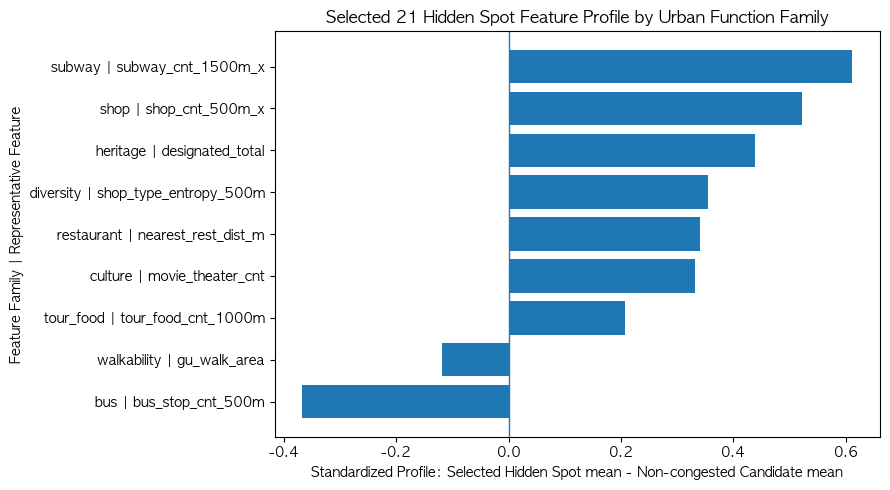

In [43]:
import matplotlib.pyplot as plt

plot_df = representative_profile_df.copy()
plot_df = plot_df.sort_values("standardized_profile_S_minus_J")

plt.figure(figsize=(9, 5))
plt.barh(
    plot_df["family"] + " | " + plot_df["feature"],
    plot_df["standardized_profile_S_minus_J"]
)
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Profile: Selected Hidden Spot mean - Non-congested Candidate mean")
plt.ylabel("Feature Family | Representative Feature")
plt.title("Selected 21 Hidden Spot Feature Profile by Urban Function Family")
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "selected_21_representative_feature_profile.png",
    dpi=300
)
plt.show()

In [44]:
top_positive_profile = (
    profile_all_df
    .sort_values("standardized_profile_S_minus_J", ascending=False)
    .head(15)
)

top_negative_profile = (
    profile_all_df
    .sort_values("standardized_profile_S_minus_J", ascending=True)
    .head(15)
)

top_positive_profile.to_csv(
    RESULT_DIR / "selected_21_top_positive_features_vs_J.csv",
    index=False,
    encoding="utf-8-sig"
)

top_negative_profile.to_csv(
    RESULT_DIR / "selected_21_top_negative_features_vs_J.csv",
    index=False,
    encoding="utf-8-sig"
)

display(top_positive_profile)
display(top_negative_profile)

,family,feature,selected_mean,non_congested_mean,raw_diff_S_minus_J,standardized_profile_S_minus_J,abs_standardized_profile
35,subway,subway_cnt_1500m_x,8.523810,6.057831,2.465979,0.612351,0.612351
20,shop,shop_cnt_500m_x,3.142857,1.713548,1.429310,0.522815,0.522815
21,shop,shop_cnt_1000m_x,7.523810,5.507229,2.016580,0.450219,0.450219
23,shop,shop_weighted_density_k20_x,0.032959,0.024713,0.008246,0.440825,0.440825
6,heritage,designated_total,64.428571,32.722760,31.705812,0.438005,0.438005
34,subway,subway_cnt_1000m_x,3.571429,2.689894,0.881535,0.407832,0.407832
5,heritage,heritage_total,124.523810,72.064834,52.458976,0.400813,0.400813
8,heritage,national_registered_cultural_property,15.666667,9.422718,6.243948,0.391133,0.391133
25,diversity,shop_type_entropy_500m,0.360497,0.232522,0.127976,0.355167,0.355167
9,heritage,city_registered_cultural_property,0.476190,0.194706,0.281485,0.351171,0.351171


,family,feature,selected_mean,non_congested_mean,raw_diff_S_minus_J,standardized_profile_S_minus_J,abs_standardized_profile
30,bus,bus_stop_cnt_500m,18.761905,21.553359,-2.791454,-0.367328,0.367328
38,subway,subway_mean_dist_k5_m_x,922.294371,1045.692291,-123.397920,-0.317746,0.317746
22,shop,nearest_shop_dist_m_x,346.430270,411.646835,-65.216565,-0.198566,0.198566
13,restaurant,rest_weighted_density_k20,0.353433,0.396609,-0.043177,-0.193002,0.193002
36,subway,nearest_subway_dist_m_x,433.571643,509.726195,-76.154552,-0.188737,0.188737
29,bus,bus_stop_cnt_300m,7.761905,8.273745,-0.511840,-0.141083,0.141083
0,walkability,gu_walk_area,250585.595238,264288.346416,-13702.751178,-0.117948,0.117948
15,tour_food,tour_food_cnt_500m,0.190476,0.210736,-0.020260,-0.027385,0.027385
10,restaurant,rest_cnt_500m,325.619048,315.688280,9.930768,0.050269,0.050269
33,subway,subway_cnt_500m_x,0.952381,0.886495,0.065886,0.078595,0.078595


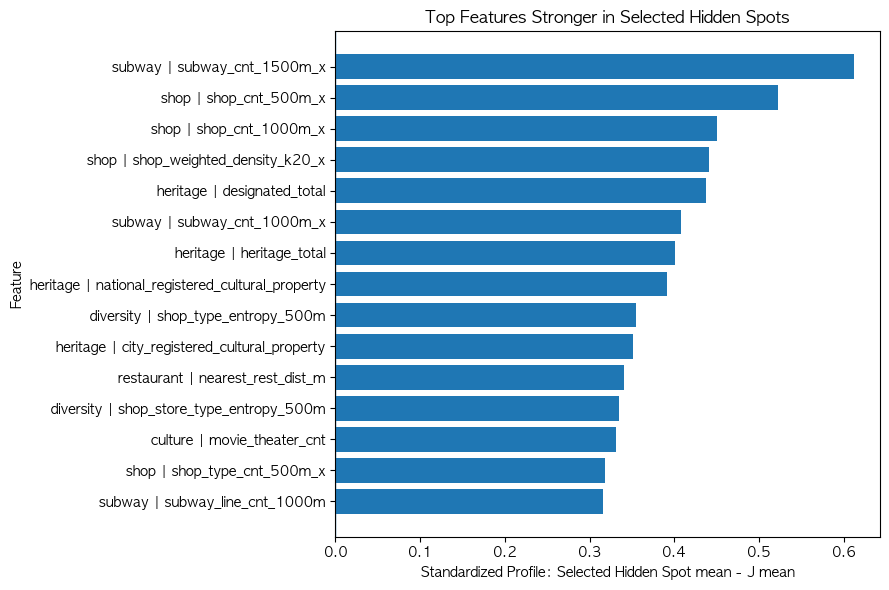

In [45]:
positive_plot_df = top_positive_profile.sort_values("standardized_profile_S_minus_J")

plt.figure(figsize=(9, 6))
plt.barh(
    positive_plot_df["family"] + " | " + positive_plot_df["feature"],
    positive_plot_df["standardized_profile_S_minus_J"]
)
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Profile: Selected Hidden Spot mean - J mean")
plt.ylabel("Feature")
plt.title("Top Features Stronger in Selected Hidden Spots")
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "selected_21_top_positive_features.png",
    dpi=300
)
plt.show()

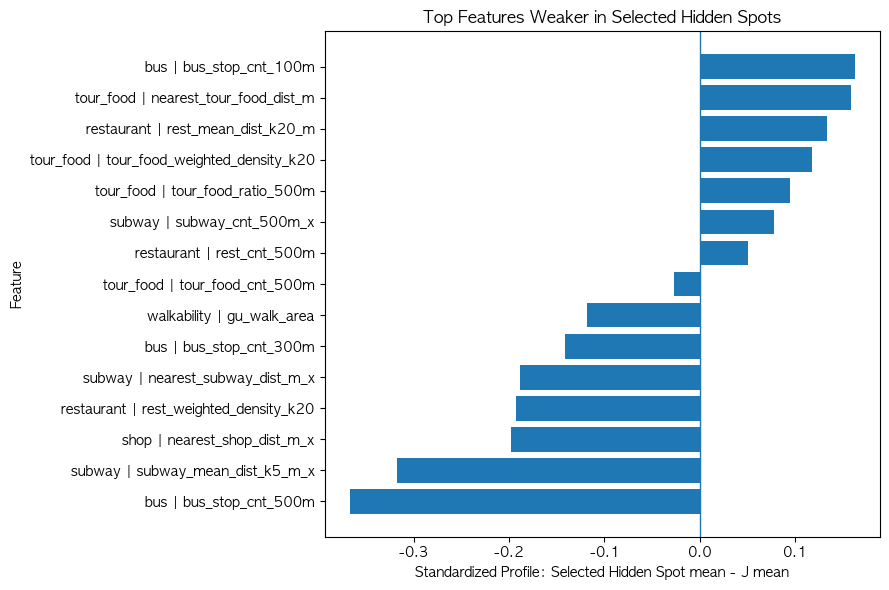

In [46]:
negative_plot_df = top_negative_profile.sort_values("standardized_profile_S_minus_J")

plt.figure(figsize=(9, 6))
plt.barh(
    negative_plot_df["family"] + " | " + negative_plot_df["feature"],
    negative_plot_df["standardized_profile_S_minus_J"]
)
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Profile: Selected Hidden Spot mean - J mean")
plt.ylabel("Feature")
plt.title("Top Features Weaker in Selected Hidden Spots")
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "selected_21_top_negative_features.png",
    dpi=300
)
plt.show()

# PART 1. Selected 21 Hidden Spot Overall Feature Profile Analysis

최종적으로 선정된 21개의 hidden spot 후보가 일반적인 비혼잡 지역(J)과 비교했을 때 어떤 도시 기능적 특성을 가지는지 분석하였다.

단순히 21개 후보의 평균값만 보는 경우 feature의 크고 작음을 해석하기 어렵기 때문에, 전체 비혼잡 후보군(J)을 기준선으로 설정하였다.

---

# 1. 분석 목적

본 단계의 목적은 다음 질문에 답하는 것이다.

```text
최종 선정된 hidden spot 후보들은
일반적인 비혼잡 지역과 비교했을 때
어떤 도시 기능적 특징을 가지는가?
````

즉 단순히 “덜 붐비는 지역”이 아니라,

* 실제 도시 기능을 충분히 보유하는지
* 특정 기능에서 강점을 가지는지
* 일반 후보군과 어떤 구조적 차이를 가지는지

를 확인하는 단계이다.

---

# 2. 분석 방법

전체 feature를 도시 기능 의미 기반의 feature family로 구분하였다.

| Feature Family | 의미       |
| -------------- | -------- |
| walkability    | 보행 수용력   |
| culture        | 문화 기능    |
| heritage       | 역사·문화 자원 |
| restaurant     | 음식 상권 기능 |
| tour_food      | 관광 음식 기능 |
| shop           | 상업 기능    |
| diversity      | 상권 다양성   |
| bus            | 버스 접근성   |
| subway         | 지하철 접근성  |

각 family 내부에서:

```text
최종 hidden spot 후보(S)와
전체 비혼잡 후보군(J) 간 평균 차이가 가장 크게 나타나는 feature
```

를 대표 feature로 선택하였다.

---

# 3. Standardized Profile Score

Feature 단위 차이를 보정하기 위해 standardized profile score를 사용하였다.

[
Profile_f =
\frac{
\mu_S(f)-\mu_J(f)
}{
\sigma_J(f)
}
]

| 기호            | 의미                      |
| ------------- | ----------------------- |
| (\mu_S(f))    | Selected Hidden Spot 평균 |
| (\mu_J(f))    | 전체 비혼잡 후보군 평균           |
| (\sigma_J(f)) | 전체 비혼잡 후보군 표준편차         |

즉:

* 양수 → Hidden Spot이 일반 후보군보다 높음
* 음수 → Hidden Spot이 일반 후보군보다 낮음

을 의미한다.

---

# 4. Representative Feature Profile 결과

| Family      | Representative Feature | 방향             |
| ----------- | ---------------------- | -------------- |
| subway      | subway_cnt_1500m_x     | Hidden Spot 우세 |
| shop        | shop_cnt_500m_x        | Hidden Spot 우세 |
| heritage    | designated_total       | Hidden Spot 우세 |
| diversity   | shop_type_entropy_500m | Hidden Spot 우세 |
| restaurant  | nearest_rest_dist_m    | Hidden Spot 우세 |
| culture     | movie_theater_cnt      | Hidden Spot 우세 |
| tour_food   | tour_food_cnt_1000m    | Hidden Spot 우세 |
| walkability | gu_walk_area           | 일반 후보군 우세      |
| bus         | bus_stop_cnt_500m      | 일반 후보군 우세      |

---

# 5. 주요 결과 해석

# (1) Hidden Spot은 높은 도시 기능을 가진 공간이다

분석 결과 hidden spot 후보는 다음 feature에서 일반 비혼잡 후보군보다 높은 값을 보였다.

| Feature                | 의미         |
| ---------------------- | ---------- |
| subway_cnt_1500m_x     | 광역 지하철 접근성 |
| shop_cnt_500m_x        | 상업 기능 밀도   |
| designated_total       | 역사·문화 자원   |
| shop_type_entropy_500m | 상권 다양성     |
| movie_theater_cnt      | 문화 시설 규모   |

즉 최종 hidden spot 후보는 단순한 저활성 지역이 아니라,

```text
상업·문화·교통 기능이 충분히 발달된 도시 공간
```

임을 확인할 수 있었다.

---

# (2) Hidden Spot은 특히 “상업 다양성”이 높다

상권 다양성을 나타내는:

* `shop_type_entropy_500m`
* `shop_store_type_entropy_500m`

feature가 모두 높은 값을 보였다.

이는 hidden spot 후보가 특정 업종 하나에 과도하게 의존하는 공간이 아니라,

```text
다양한 소비 활동이 공존하는 복합 상권 구조
```

를 가진다는 의미이다.

즉 단순 관광 특화 지역보다:

* 생활 소비
* 음식 소비
* 문화 소비

가 함께 존재하는 공간일 가능성을 시사한다.

---

# (3) Hidden Spot은 역사·문화 자원이 강하다

다음 heritage 계열 feature가 높은 값을 보였다.

| Feature                               | 의미         |
| ------------------------------------- | ---------- |
| designated_total                      | 전체 지정 문화자원 |
| heritage_total                        | 전체 문화유산    |
| national_registered_cultural_property | 국가 등록 문화재  |

즉 hidden spot 후보는 단순 상업 지역이 아니라,

```text
역사·문화 자원을 충분히 보유한 잠재 공간
```

이라는 특징을 가진다.

이는 향후 관광·문화 기반 수요 분산 가능성을 시사한다.

---

# (4) Hidden Spot은 광역 접근성이 강하다

특히:

| Feature               | 결과    |
| --------------------- | ----- |
| subway_cnt_1500m_x    | 매우 높음 |
| subway_cnt_1000m_x    | 높음    |
| subway_line_cnt_1000m | 높음    |

이 나타났다.

즉 hidden spot 후보는:

```text
도시 전체 관점에서는 충분한 접근성을 보유하지만,
초고밀 집중은 아직 발생하지 않은 공간
```

으로 해석할 수 있다.

---

# (5) Hidden Spot은 “초근접 고밀도 집중”은 상대적으로 약하다

반면 다음 feature는 상대적으로 낮았다.

| Feature                   | 의미         |
| ------------------------- | ---------- |
| bus_stop_cnt_500m         | 초고밀 버스 접근성 |
| rest_weighted_density_k20 | 극단적 음식점 밀집 |
| nearest_shop_dist_m_x     | 초근접 상업 응집  |

즉 hidden spot 후보는:

```text
기본적인 도시 기능은 충분히 보유하지만,
일부 hotplace에서 나타나는 초고밀 집중 구조는 상대적으로 약한 공간
```

이라는 특징을 보였다.

---

# 6. 종합 해석

종합하면 최종 선정된 21개의 hidden spot 후보는:

* 상업 기능
* 교통 접근성
* 문화 기능
* 역사 자원
* 소비 다양성

등 주요 도시 기능을 충분히 보유하면서도,

```text
초고밀 교통 집중 및 극단적 상업 응집은 아직 상대적으로 약한 공간
```

으로 나타났다.

즉 본 연구의 hidden spot 후보는 단순 저활성 지역이 아니라,

```text
기능적으로는 충분히 성숙했지만
아직 과잉 집중이 발생하지 않은 잠재적 수요 분산 공간
```

으로 해석할 수 있다.

```
```


### **PART2: Hotplace vs Hidden Spot 차이 분석**

In [5]:
group_summary = pd.DataFrame({
    "H_mean": H[feature_cols].mean(numeric_only=True),
    "S_mean": S[feature_cols].mean(numeric_only=True),
    "J_mean": J[feature_cols].mean(numeric_only=True)
})

group_summary["H_minus_S"] = group_summary["H_mean"] - group_summary["S_mean"]
group_summary["S_minus_J"] = group_summary["S_mean"] - group_summary["J_mean"]
group_summary["S_over_H"] = group_summary["S_mean"] / group_summary["H_mean"].replace(0, np.nan)
group_summary["S_over_J"] = group_summary["S_mean"] / group_summary["J_mean"].replace(0, np.nan)

group_summary = group_summary.sort_values("H_minus_S", ascending=False)

group_summary.to_csv(RESULT_DIR / "hotplace_hidden_spot_feature_gap.csv", encoding="utf-8-sig")

group_summary

,H_mean,S_mean,J_mean,H_minus_S,S_minus_J,S_over_H,S_over_J
gu_walk_area,310171.199747,250585.595238,264288.346416,59585.604508,-13702.751178,0.807894,0.948152
rest_cnt_1000m,1301.832381,1058.666667,937.937429,243.165714,120.729238,0.813213,1.128718
rest_cnt_500m,450.236824,325.619048,315.688280,124.617776,9.930768,0.723217,1.031458
bus_stop_cnt_500m,23.045403,18.761905,21.553359,4.283498,-2.791454,0.814128,0.870486
subway_cnt_1000m_x,4.037117,3.571429,2.689894,0.465688,0.881535,0.884648,1.327721
tour_food_cnt_500m,0.557378,0.190476,0.210736,0.366902,-0.020260,0.341736,0.903860
shop_cnt_1000m_x,7.834066,7.523810,5.507229,0.310257,2.016580,0.960396,1.366170
movie_screen_cnt,28.480171,28.285714,25.604203,0.194456,2.681512,0.993172,1.104729
movie_theater_cnt,5.138142,4.952381,4.239066,0.185761,0.713315,0.963847,1.168272
subway_line_cnt_1000m,2.210479,2.047619,1.669903,0.162860,0.377716,0.926324,1.226190


In [6]:
top_higher_in_H = group_summary.sort_values("H_minus_S", ascending=False).head(15)
top_higher_in_S = group_summary.sort_values("H_minus_S", ascending=True).head(15)

top_higher_in_H.to_csv(RESULT_DIR / "features_higher_in_hotplace.csv", encoding="utf-8-sig")
top_higher_in_S.to_csv(RESULT_DIR / "features_higher_in_hidden_spot.csv", encoding="utf-8-sig")

display(top_higher_in_H)
display(top_higher_in_S)

,H_mean,S_mean,J_mean,H_minus_S,S_minus_J,S_over_H,S_over_J
gu_walk_area,310171.199747,250585.595238,264288.346416,59585.604508,-13702.751178,0.807894,0.948152
rest_cnt_1000m,1301.832381,1058.666667,937.937429,243.165714,120.729238,0.813213,1.128718
rest_cnt_500m,450.236824,325.619048,315.688280,124.617776,9.930768,0.723217,1.031458
bus_stop_cnt_500m,23.045403,18.761905,21.553359,4.283498,-2.791454,0.814128,0.870486
subway_cnt_1000m_x,4.037117,3.571429,2.689894,0.465688,0.881535,0.884648,1.327721
tour_food_cnt_500m,0.557378,0.190476,0.210736,0.366902,-0.020260,0.341736,0.903860
shop_cnt_1000m_x,7.834066,7.523810,5.507229,0.310257,2.016580,0.960396,1.366170
movie_screen_cnt,28.480171,28.285714,25.604203,0.194456,2.681512,0.993172,1.104729
movie_theater_cnt,5.138142,4.952381,4.239066,0.185761,0.713315,0.963847,1.168272
subway_line_cnt_1000m,2.210479,2.047619,1.669903,0.162860,0.377716,0.926324,1.226190


,H_mean,S_mean,J_mean,H_minus_S,S_minus_J,S_over_H,S_over_J
nearest_subway_dist_m_x,390.460050,433.571643,509.726195,-43.111593,-76.154552,1.110412,0.850597
movie_seat_cnt,4151.267687,4191.809524,3780.054987,-40.541837,411.754537,1.009766,1.108928
heritage_total,88.436541,124.523810,72.064834,-36.087268,52.458976,1.408058,1.727941
designated_total,42.600131,64.428571,32.722760,-21.828440,31.705812,1.512403,1.968922
city_designated_total,30.061100,38.523810,25.965065,-8.462709,12.558745,1.281517,1.483679
concert_total,28.042569,32.523810,22.166158,-4.481241,10.357651,1.159801,1.467273
subway_cnt_1500m_x,7.995205,8.523810,6.057831,-0.528604,2.465979,1.066115,1.407073
tour_food_cnt_1000m,1.379398,1.571429,0.885166,-0.192030,0.686263,1.139213,1.775293
shop_store_type_entropy_500m,0.150890,0.251474,0.157950,-0.100585,0.093524,1.666610,1.592111
shop_store_type_cnt_500m,0.947238,1.047619,0.888372,-0.100381,0.159247,1.105972,1.179257


In [7]:
profile_cols = [
    "selection_order",
    "nearest_local_자치구",
    "nearest_local_상권명",
    "nearest_local_매칭_행정동",
    "nearest_local_매칭_상권_구분",
    "위도",
    "경도",
    "hour",
    "weekday",
    "covered_h_count",
    "pair_count",
    "avg_x_sim",
    "avg_c_sim_scaled",
    "avg_rank",
    "avg_time_diff",
    "nearest_local_dist_m",
    "rest_cnt_500m",
    "rest_weighted_density_k20",
    "shop_cnt_500m_x",
    "shop_weighted_density_k20_x",
    "shop_type_entropy_500m",
    "tour_food_ratio_500m",
    "bus_stop_cnt_500m",
    "subway_cnt_1000m_x",
    "nearest_subway_dist_m_x",
    "subway_weighted_access_k5_x",
    "subway_line_entropy_1000m",
    "concert_total",
    "movie_seat_cnt",
    "heritage_total",
    "city_designated_total"
]

profile_cols = [c for c in profile_cols if c in S.columns]

S_profile = S[profile_cols].copy()
S_profile = S_profile.sort_values("selection_order")

S_profile.to_csv(RESULT_DIR / "selected_21_profile_table.csv", index=False, encoding="utf-8-sig")

S_profile

,selection_order,nearest_local_자치구,nearest_local_상권명,nearest_local_매칭_행정동,nearest_local_매칭_상권_구분,위도,경도,hour,weekday,covered_h_count,...,tour_food_ratio_500m,bus_stop_cnt_500m,subway_cnt_1000m_x,nearest_subway_dist_m_x,subway_weighted_access_k5_x,subway_line_entropy_1000m,concert_total,movie_seat_cnt,heritage_total,city_designated_total
0,1,종로구,서촌,사직동,발달상권,37.582331,126.983559,13,5,29,...,0.005587,26,1,671.781587,0.004654,-1.000000e-09,161,3648,483,173
1,2,강북구,수유,수유3동,발달상권,37.630376,127.022628,10,6,5,...,0.000000,19,4,507.042957,0.007487,6.931472e-01,6,2515,33,21
2,3,종로구,서촌,사직동,발달상권,37.563846,126.981866,8,0,14,...,0.000000,32,9,249.998392,0.011319,1.522955e+00,29,4188,108,30
3,4,강북구,수유,수유3동,발달상권,37.640683,127.035490,3,3,6,...,0.000000,22,2,885.962134,0.004096,-1.000000e-09,5,1550,16,13
4,5,강북구,수유,수유3동,발달상권,37.637817,127.038271,5,0,5,...,0.000000,22,0,1104.410897,0.003572,0.000000e+00,5,1550,16,13
5,6,중구,광희동 중앙아시아거리,광희동,관광특구,37.578786,127.007188,6,0,11,...,0.000000,10,5,614.485905,0.006312,1.054920e+00,161,3648,483,173
6,7,중구,광희동 중앙아시아거리,광희동,관광특구,37.567729,127.012670,5,1,15,...,0.000000,22,11,352.917284,0.011587,1.594167e+00,29,4188,108,30
7,8,강서구,마곡 미술길,가양1동,발달상권,37.560034,126.825876,7,0,11,...,0.000000,21,3,41.177761,0.028421,1.098612e+00,6,4983,15,7
8,9,광진구,건대입구 청춘대로,화양동,발달상권,37.537680,127.085212,10,5,11,...,0.000000,15,2,91.362797,0.014095,-1.000000e-09,16,6548,30,6
9,10,중구,광희동 중앙아시아거리,광희동,관광특구,37.577740,127.008033,8,0,11,...,0.000000,9,7,670.148002,0.006629,1.078992e+00,161,3648,483,173


In [8]:
score_cols = [
    "covered_h_count",
    "avg_x_sim",
    "avg_c_sim_scaled",
    "nearest_local_dist_m",
    "rest_weighted_density_k20",
    "shop_weighted_density_k20_x",
    "subway_weighted_access_k5_x",
    "shop_type_entropy_500m"
]

score_cols = [c for c in score_cols if c in S.columns]

score_df = S.copy()

for col in score_cols:
    score_df[col] = pd.to_numeric(score_df[col], errors="coerce")

for col in score_cols:
    min_v = score_df[col].min()
    max_v = score_df[col].max()
    if max_v != min_v:
        score_df[f"{col}_norm"] = (score_df[col] - min_v) / (max_v - min_v)
    else:
        score_df[f"{col}_norm"] = 0

if "nearest_local_dist_m_norm" in score_df.columns:
    score_df["local_proximity_score"] = 1 - score_df["nearest_local_dist_m_norm"]
else:
    score_df["local_proximity_score"] = 0

score_df["hidden_spot_score"] = (
    0.25 * score_df.get("covered_h_count_norm", 0) +
    0.20 * score_df.get("avg_x_sim_norm", 0) +
    0.20 * score_df.get("avg_c_sim_scaled_norm", 0) +
    0.15 * score_df["local_proximity_score"] +
    0.10 * score_df.get("rest_weighted_density_k20_norm", 0) +
    0.10 * score_df.get("subway_weighted_access_k5_x_norm", 0)
)

rank_cols = [
    "selection_order",
    "nearest_local_자치구",
    "nearest_local_상권명",
    "nearest_local_매칭_행정동",
    "covered_h_count",
    "avg_x_sim",
    "avg_c_sim_scaled",
    "nearest_local_dist_m",
    "hidden_spot_score"
]

rank_cols = [c for c in rank_cols if c in score_df.columns]

S_ranked = score_df[rank_cols].sort_values("hidden_spot_score", ascending=False)

S_ranked.to_csv(RESULT_DIR / "selected_21_hidden_spot_score_rank.csv", index=False, encoding="utf-8-sig")

S_ranked

,selection_order,nearest_local_자치구,nearest_local_상권명,nearest_local_매칭_행정동,covered_h_count,avg_x_sim,avg_c_sim_scaled,nearest_local_dist_m,hidden_spot_score
6,7,중구,광희동 중앙아시아거리,광희동,15,0.995643,0.999481,131.087451,0.651767
20,21,강동구,천호자전거거리,천호2동,3,0.997321,1.000000,865.296767,0.593848
0,1,종로구,서촌,사직동,29,0.991305,0.998278,1088.362469,0.535647
11,12,노원구,경춘선공릉숲길,공릉1동,3,0.996626,1.000000,528.199998,0.530285
17,18,강동구,천호자전거거리,천호2동,3,0.996409,1.000000,876.918764,0.523802
13,14,동작구,노량진 만나로,노량진1동,3,0.997478,1.000000,1695.817204,0.472692
14,15,서초구,케미스트릿강남역,서초2동,11,0.992890,0.999466,1309.404298,0.470411
16,17,광진구,건대입구 청춘대로,화양동,3,0.996451,1.000000,1286.990417,0.465386
8,9,광진구,건대입구 청춘대로,화양동,11,0.991006,0.998865,1428.060017,0.457553
1,2,강북구,수유,수유3동,5,0.993624,1.000000,846.904558,0.447306


In [34]:
feature_groups = {
    "walkability": [
        "gu_walk_area"
    ],
    "culture": [
        "concert_total",
        "movie_theater_cnt",
        "movie_screen_cnt",
        "movie_seat_cnt"
    ],
    "heritage": [
        "heritage_total",
        "designated_total",
        "city_designated_total",
        "national_registered_cultural_property",
        "city_registered_cultural_property"
    ],
    "restaurant": [
        "rest_cnt_500m",
        "rest_cnt_1000m",
        "nearest_rest_dist_m",
        "rest_weighted_density_k20",
        "rest_mean_dist_k20_m"
    ],
    "tour_food": [
        "tour_food_cnt_500m",
        "tour_food_cnt_1000m",
        "nearest_tour_food_dist_m",
        "tour_food_weighted_density_k20",
        "tour_food_ratio_500m"
    ],
    "shop": [
        "shop_cnt_500m_x",
        "shop_cnt_1000m_x",
        "nearest_shop_dist_m_x",
        "shop_weighted_density_k20_x",
        "shop_type_cnt_500m_x"
    ],
    "diversity": [
        "shop_type_entropy_500m",
        "shop_store_type_cnt_500m",
        "shop_store_type_entropy_500m"
    ],
    "bus": [
        "bus_stop_cnt_100m",
        "bus_stop_cnt_300m",
        "bus_stop_cnt_500m",
        "bus_info_cnt_300m"
    ],
    "subway": [
        "subway_cnt_300m_x",
        "subway_cnt_500m_x",
        "subway_cnt_1000m_x",
        "subway_cnt_1500m_x",
        "nearest_subway_dist_m_x",
        "subway_weighted_access_k5_x",
        "subway_mean_dist_k5_m_x",
        "subway_line_cnt_1000m",
        "subway_line_entropy_1000m"
    ]
}

available_feature_groups = {
    group: [c for c in cols if c in S.columns and c in H.columns]
    for group, cols in feature_groups.items()
}

available_feature_groups = {
    group: cols
    for group, cols in available_feature_groups.items()
    if len(cols) > 0
}

available_feature_groups

{'walkability': ['gu_walk_area'],
 'culture': ['concert_total',
  'movie_theater_cnt',
  'movie_screen_cnt',
  'movie_seat_cnt'],
 'heritage': ['heritage_total',
  'designated_total',
  'city_designated_total',
  'national_registered_cultural_property',
  'city_registered_cultural_property'],
 'restaurant': ['rest_cnt_500m',
  'rest_cnt_1000m',
  'nearest_rest_dist_m',
  'rest_weighted_density_k20',
  'rest_mean_dist_k20_m'],
 'tour_food': ['tour_food_cnt_500m',
  'tour_food_cnt_1000m',
  'nearest_tour_food_dist_m',
  'tour_food_weighted_density_k20',
  'tour_food_ratio_500m'],
 'shop': ['shop_cnt_500m_x',
  'shop_cnt_1000m_x',
  'nearest_shop_dist_m_x',
  'shop_weighted_density_k20_x',
  'shop_type_cnt_500m_x'],
 'diversity': ['shop_type_entropy_500m',
  'shop_store_type_cnt_500m',
  'shop_store_type_entropy_500m'],
 'bus': ['bus_stop_cnt_100m',
  'bus_stop_cnt_300m',
  'bus_stop_cnt_500m',
  'bus_info_cnt_300m'],
 'subway': ['subway_cnt_300m_x',
  'subway_cnt_500m_x',
  'subway_cnt_1

In [35]:
all_candidate_features = []

for group, cols in available_feature_groups.items():
    all_candidate_features.extend(cols)

all_candidate_features = list(dict.fromkeys(all_candidate_features))

feature_gap_all = pd.DataFrame({
    "feature": all_candidate_features,
    "family": [
        group
        for feature in all_candidate_features
        for group, cols in available_feature_groups.items()
        if feature in cols
    ]
})

for col in all_candidate_features:
    H[col] = pd.to_numeric(H[col], errors="coerce")
    S[col] = pd.to_numeric(S[col], errors="coerce")

gap_records = []

for group, cols in available_feature_groups.items():
    for col in cols:
        h_mean = H[col].mean()
        s_mean = S[col].mean()
        h_std = H[col].std()
        
        standardized_gap = (h_mean - s_mean) / h_std if h_std != 0 else np.nan
        
        gap_records.append({
            "family": group,
            "feature": col,
            "hotplace_mean": h_mean,
            "hidden_spot_mean": s_mean,
            "raw_gap_H_minus_S": h_mean - s_mean,
            "standardized_gap_H_minus_S": standardized_gap,
            "abs_standardized_gap": abs(standardized_gap)
        })

gap_all_df = pd.DataFrame(gap_records)

gap_all_df = gap_all_df.sort_values(
    ["family", "abs_standardized_gap"],
    ascending=[True, False]
)

gap_all_df.to_csv(
    RESULT_DIR / "hotplace_hidden_spot_all_feature_gap_by_family.csv",
    index=False,
    encoding="utf-8-sig"
)

gap_all_df

,family,feature,hotplace_mean,hidden_spot_mean,raw_gap_H_minus_S,standardized_gap_H_minus_S,abs_standardized_gap
30,bus,bus_stop_cnt_500m,23.045403,18.761905,4.283498,0.518468,0.518468
29,bus,bus_stop_cnt_300m,9.109709,7.761905,1.347805,0.319718,0.319718
28,bus,bus_stop_cnt_100m,1.844037,1.666667,0.177370,0.097555,0.097555
31,bus,bus_info_cnt_300m,0.000000,0.000000,0.000000,NaN,NaN
1,culture,concert_total,28.042569,32.523810,-4.481241,-0.111403,0.111403
2,culture,movie_theater_cnt,5.138142,4.952381,0.185761,0.079207,0.079207
4,culture,movie_seat_cnt,4151.267687,4191.809524,-40.541837,-0.022781,0.022781
3,culture,movie_screen_cnt,28.480171,28.285714,0.194456,0.015743,0.015743
27,diversity,shop_store_type_entropy_500m,0.150890,0.251474,-0.100585,-0.364267,0.364267
26,diversity,shop_store_type_cnt_500m,0.947238,1.047619,-0.100381,-0.139946,0.139946


In [36]:
representative_gap_df = (
    gap_all_df
    .sort_values(["family", "abs_standardized_gap"], ascending=[True, False])
    .groupby("family", as_index=False)
    .head(1)
    .sort_values("abs_standardized_gap", ascending=False)
)

representative_gap_cols = representative_gap_df["feature"].tolist()

representative_gap_df.to_csv(
    RESULT_DIR / "hotplace_hidden_spot_representative_feature_gap.csv",
    index=False,
    encoding="utf-8-sig"
)
representative_gap_df

,family,feature,hotplace_mean,hidden_spot_mean,raw_gap_H_minus_S,standardized_gap_H_minus_S,abs_standardized_gap
12,restaurant,nearest_rest_dist_m,38.991678,64.207884,-25.216206,-0.542976,0.542976
30,bus,bus_stop_cnt_500m,23.045403,18.761905,4.283498,0.518468,0.518468
0,walkability,gu_walk_area,310171.199747,250585.595238,59585.604508,0.422600,0.422600
9,heritage,city_registered_cultural_property,0.188819,0.476190,-0.287372,-0.374669,0.374669
27,diversity,shop_store_type_entropy_500m,0.150890,0.251474,-0.100585,-0.364267,0.364267
17,tour_food,nearest_tour_food_dist_m,2217.512046,2852.199941,-634.687895,-0.299080,0.299080
33,subway,subway_cnt_500m_x,1.279211,0.952381,0.326830,0.293219,0.293219
1,culture,concert_total,28.042569,32.523810,-4.481241,-0.111403,0.111403
24,shop,shop_type_cnt_500m_x,1.524324,1.380952,0.143372,0.104799,0.104799


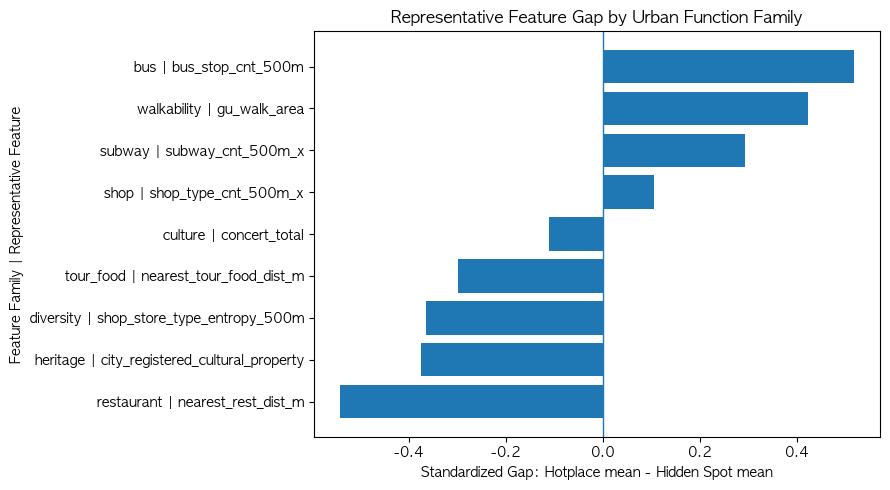

In [37]:
import matplotlib.pyplot as plt

plot_df = representative_gap_df.copy()
plot_df = plot_df.sort_values("standardized_gap_H_minus_S")

plt.figure(figsize=(9, 5))
plt.barh(
    plot_df["family"] + " | " + plot_df["feature"],
    plot_df["standardized_gap_H_minus_S"]
)
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Gap: Hotplace mean - Hidden Spot mean")
plt.ylabel("Feature Family | Representative Feature")
plt.title("Representative Feature Gap by Urban Function Family")
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "representative_feature_gap_by_family.png",
    dpi=300
)
plt.show()

In [38]:
interpret_df = representative_gap_df.copy()

def gap_direction(x):
    if pd.isna(x):
        return "비교 불가"
    elif x > 0:
        return "Hotplace가 더 높음"
    elif x < 0:
        return "Hidden Spot이 더 높음"
    else:
        return "차이 없음"

interpret_df["direction"] = interpret_df["standardized_gap_H_minus_S"].apply(gap_direction)

interpret_df = interpret_df[
    [
        "family",
        "feature",
        "hotplace_mean",
        "hidden_spot_mean",
        "raw_gap_H_minus_S",
        "standardized_gap_H_minus_S",
        "direction"
    ]
].round(4)

interpret_df.to_csv(
    RESULT_DIR / "representative_feature_gap_interpret_table.csv",
    index=False,
    encoding="utf-8-sig"
)

interpret_df

,family,feature,hotplace_mean,hidden_spot_mean,raw_gap_H_minus_S,standardized_gap_H_minus_S,direction
12,restaurant,nearest_rest_dist_m,38.9917,64.2079,-25.2162,-0.5430,Hidden Spot이 더 높음
30,bus,bus_stop_cnt_500m,23.0454,18.7619,4.2835,0.5185,Hotplace가 더 높음
0,walkability,gu_walk_area,310171.1997,250585.5952,59585.6045,0.4226,Hotplace가 더 높음
9,heritage,city_registered_cultural_property,0.1888,0.4762,-0.2874,-0.3747,Hidden Spot이 더 높음
27,diversity,shop_store_type_entropy_500m,0.1509,0.2515,-0.1006,-0.3643,Hidden Spot이 더 높음
17,tour_food,nearest_tour_food_dist_m,2217.5120,2852.1999,-634.6879,-0.2991,Hidden Spot이 더 높음
33,subway,subway_cnt_500m_x,1.2792,0.9524,0.3268,0.2932,Hotplace가 더 높음
1,culture,concert_total,28.0426,32.5238,-4.4812,-0.1114,Hidden Spot이 더 높음
24,shop,shop_type_cnt_500m_x,1.5243,1.3810,0.1434,0.1048,Hotplace가 더 높음


# Hotplace vs Hidden Spot Feature Gap Analysis

최종적으로 선정된 hidden spot 후보가 단순히 “덜 활성화된 지역”인지, 혹은 실제 hotplace와 구조적으로 유사한 기능을 가지는지 확인하기 위해 Hotplace(H)와 Hidden Spot(S) 간 feature gap 분석을 수행하였다.

---

# 1. 분석 목적

본 단계의 핵심 목적은 다음 질문에 답하는 것이다.

```text
왜 Hidden Spot은 Hotplace와 유사하면서도
아직 과도하게 혼잡하지 않은가?
````

즉 단순히 similarity score만 비교하는 것이 아니라,

* 교통 접근성
* 상업 기능
* 문화 기능
* 관광 기능
* 상권 다양성

등 실제 도시 기능(feature) 수준에서 어떤 차이가 존재하는지 분석하였다.

---

# 2. Feature 선택 방식

본 분석에서는 일부 feature를 임의로 선택하지 않고, 도시 기능을 설명하는 변수들을 의미 기반의 feature family로 구분하였다.

## 사용한 도시 기능 family

| Feature Family | 의미          |
| -------------- | ----------- |
| walkability    | 보행 수용력      |
| culture        | 문화 활동성      |
| heritage       | 역사·문화 자원    |
| restaurant     | 음식 상권 기능    |
| tour_food      | 관광 음식 소비 기능 |
| shop           | 상업 기능       |
| diversity      | 상권 다양성      |
| bus            | 버스 접근성      |
| subway         | 지하철 접근성     |

---

# 3. Representative Feature 선택 방식

각 family 내부에는 여러 feature가 존재하기 때문에, Hotplace와 Hidden Spot 간 평균 차이가 가장 크게 나타나는 대표 feature를 자동 선택하였다.

이때 단위가 서로 다른 feature 간 비교를 위해 단순 평균 차이가 아니라 standardized gap을 사용하였다.

## Standardized Gap

다음과 같이 정의하였다.

[
Gap_f =
\frac{
\mu_H(f)-\mu_S(f)
}{
\sigma_H(f)
}
]

| 기호            | 의미             |
| ------------- | -------------- |
| (\mu_H(f))    | Hotplace 평균    |
| (\mu_S(f))    | Hidden Spot 평균 |
| (\sigma_H(f)) | Hotplace 표준편차  |

즉:

* 양수 → Hotplace가 더 높음
* 음수 → Hidden Spot이 더 높음

을 의미한다.

---

# 4. Representative Feature Gap 결과

| Family      | Representative Feature            | 방향                |
| ----------- | --------------------------------- | ----------------- |
| restaurant  | nearest_rest_dist_m               | Hidden Spot이 더 높음 |
| bus         | bus_stop_cnt_500m                 | Hotplace가 더 높음    |
| walkability | gu_walk_area                      | Hotplace가 더 높음    |
| heritage    | city_registered_cultural_property | Hidden Spot이 더 높음 |
| diversity   | shop_store_type_entropy_500m      | Hidden Spot이 더 높음 |
| tour_food   | nearest_tour_food_dist_m          | Hidden Spot이 더 높음 |
| subway      | subway_cnt_500m_x                 | Hotplace가 더 높음    |
| culture     | concert_total                     | Hidden Spot이 더 높음 |
| shop        | shop_type_cnt_500m_x              | Hotplace가 더 높음    |

---

# 5. 주요 해석

# (1) Hidden Spot은 기능이 부족한 지역이 아니다

분석 결과 Hidden Spot은 다음 feature에서 오히려 높은 값을 보였다.

| Feature   | 결과             |
| --------- | -------------- |
| heritage  | Hidden Spot 우세 |
| diversity | Hidden Spot 우세 |
| culture   | Hidden Spot 우세 |

즉 Hidden Spot은 단순히 기능이 부족하거나 저활성화된 공간이 아니라,

```text
문화·역사·상업 다양성 등 주요 도시 기능을 충분히 보유한 공간
```

임을 확인할 수 있었다.

---

# (2) Hotplace는 초고밀 접근성이 강하다

반면 Hotplace는 다음 feature에서 높은 값을 보였다.

| Feature           | 결과          |
| ----------------- | ----------- |
| bus_stop_cnt_500m | Hotplace 우세 |
| subway_cnt_500m_x | Hotplace 우세 |
| gu_walk_area      | Hotplace 우세 |

즉 Hotplace는:

```text
초고밀 교통 접근성과 대규모 보행 수용력을 가진 공간
```

이라는 특징을 보였다.

이는 실제 혼잡 발생이 단순 기능 부족 여부보다:

* 교통 집중성
* 접근성 집중
* 대규모 유동 인구 수용 구조

와 더 강하게 연결될 가능성을 시사한다.

---

# (3) Hidden Spot은 “잠재적 대체지”로 해석 가능하다

특히 Hidden Spot은:

* 상권 다양성은 높고
* 문화·역사 자원도 충분하며
* 소비 기능 역시 일정 수준 유지됨에도

아직 초고밀 교통 집중 구조가 상대적으로 약한 특징을 보였다.

즉 Hidden Spot은:

```text
기능적으로는 Hotplace와 유사하지만,
아직 특정 집중 메커니즘이 과도하게 활성화되지 않은 공간
```

으로 해석할 수 있다.

---

# 6. 결과 해석의 의미

본 결과는 Hidden Spot이 단순히 “열등한 대체지”가 아니라,

```text
실제 도시 기능을 충분히 보유하면서도
현재 혼잡도가 상대적으로 낮은 잠재적 수요 분산 공간
```

일 가능성을 시사한다.

즉 본 연구는 단순 관광 추천이 아니라,

```text
도시 혼잡 완화를 위한 수요 재분산 가능성 탐색
```

이라는 측면에서 의미를 가진다.

```
```


### **PART3: Hidden Spot 유형화**

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

cluster_cols = [
    "rest_weighted_density_k20",
    "shop_weighted_density_k20_x",
    "shop_type_entropy_500m",
    "shop_store_type_entropy_500m",
    "subway_weighted_access_k5_x",
    "bus_stop_cnt_500m",
    "tour_food_ratio_500m",
    "heritage_total",
    "concert_total",
    "movie_seat_cnt"
]

cluster_cols = [c for c in cluster_cols if c in S.columns]

cluster_df = S.copy()

for col in cluster_cols:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

X_cluster = cluster_df[cluster_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X_cluster)

k_range = range(2, min(9, len(cluster_df)))

k_result = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    k_result.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette
    })

k_result_df = pd.DataFrame(k_result)

k_result_df["inertia_norm"] = (
    (k_result_df["inertia"] - k_result_df["inertia"].min()) /
    (k_result_df["inertia"].max() - k_result_df["inertia"].min())
)

k_result_df["silhouette_norm"] = (
    (k_result_df["silhouette"] - k_result_df["silhouette"].min()) /
    (k_result_df["silhouette"].max() - k_result_df["silhouette"].min())
)

k_result_df["score"] = (
    0.5 * (1 - k_result_df["inertia_norm"]) +
    0.5 * k_result_df["silhouette_norm"]
)

best_k = int(k_result_df.sort_values("score", ascending=False).iloc[0]["k"])

k_result_df.to_csv(
    RESULT_DIR / "selected_21_cluster_k_selection.csv",
    index=False,
    encoding="utf-8-sig"
)

print("best_k:", best_k)
k_result_df

best_k: 8


,k,inertia,silhouette,inertia_norm,silhouette_norm,score
0,2,155.335920,0.299207,1.000000,1.000000,0.500000
1,3,119.607021,0.214654,0.684129,0.000000,0.157936
2,4,100.087464,0.241677,0.511561,0.319602,0.404021
3,5,78.993792,0.260530,0.325076,0.542568,0.608746
4,6,61.981160,0.268784,0.174671,0.640199,0.732764
5,7,50.907638,0.273591,0.076772,0.697051,0.810139
6,8,42.223738,0.292852,0.000000,0.924848,0.962424


In [12]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    cluster_df
    .groupby("cluster")[cluster_cols]
    .mean()
    .round(3)
)

cluster_count = (
    cluster_df
    .groupby("cluster")
    .agg(
        candidate_count=("selection_order", "count"),
        total_covered_h=("covered_h_count", "sum"),
        avg_x_sim=("avg_x_sim", "mean"),
        avg_c_sim_scaled=("avg_c_sim_scaled", "mean"),
        avg_local_dist_m=("nearest_local_dist_m", "mean")
    )
    .round(3)
)

cluster_result = cluster_count.join(cluster_profile)

cluster_result.to_csv(
    RESULT_DIR / "selected_21_cluster_profile.csv",
    encoding="utf-8-sig"
)

cluster_result

,candidate_count,total_covered_h,avg_x_sim,avg_c_sim_scaled,avg_local_dist_m,rest_weighted_density_k20,shop_weighted_density_k20_x,shop_type_entropy_500m,shop_store_type_entropy_500m,subway_weighted_access_k5_x,bus_stop_cnt_500m,tour_food_ratio_500m,heritage_total,concert_total,movie_seat_cnt
cluster,,,,,,,,,,,,,,,
0,2,44,0.992,0.983,876.600,0.386,0.013,-0.000,-0.000,0.005,21.00,0.008,465.000,86.500,4949.000
1,4,16,0.996,0.997,1236.540,0.325,0.015,-0.000,-0.000,0.011,13.25,0.000,12.750,8.500,5585.750
2,4,17,0.996,1.000,1012.681,0.338,0.038,0.655,0.655,0.007,23.50,0.000,37.000,4.750,2165.750
3,2,29,0.994,0.985,1031.262,0.275,0.114,0.914,-0.000,0.011,27.00,0.000,108.000,29.000,4188.000
4,2,14,0.994,0.972,419.063,0.206,0.024,0.868,0.637,0.024,20.00,0.000,15.000,6.000,4983.000
5,2,22,0.992,0.999,1368.732,0.790,0.042,0.693,0.693,0.013,14.50,0.001,38.500,24.000,6867.500
6,2,22,0.994,0.982,1258.963,0.322,0.020,0.000,0.000,0.006,9.50,0.000,483.000,161.000,3648.000
7,3,11,0.996,0.991,1387.041,0.269,0.017,-0.000,-0.000,0.006,21.00,0.000,65.667,5.667,2583.667


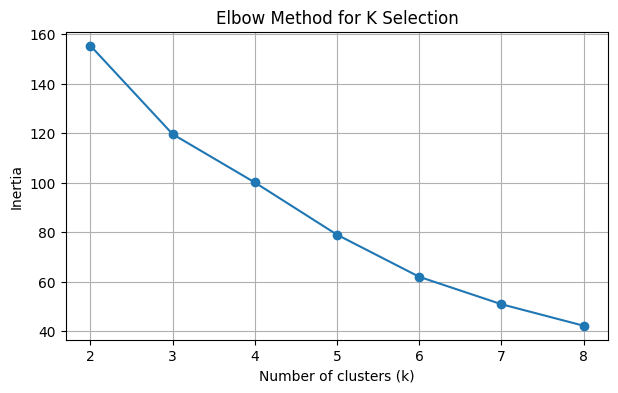

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(k_result_df["k"], k_result_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K Selection")
plt.grid(True)
plt.show()

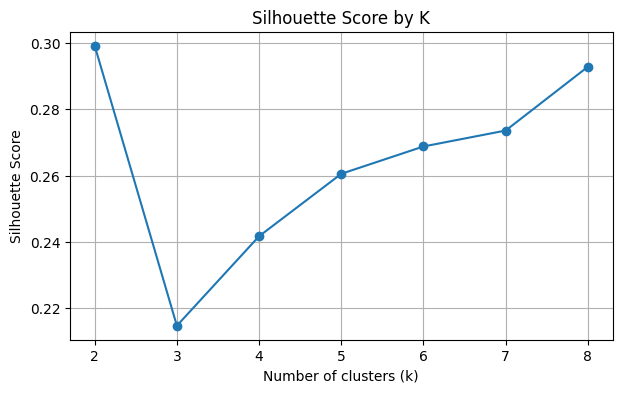

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(k_result_df["k"], k_result_df["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.grid(True)
plt.show()

**k=5로 클러스터 수 결정**

| 이유         | 설명                    |
| ---------- | --------------------- |
| sample 수   | 21개라 너무 많은 cluster 위험 |
| elbow      | 5 근처부터 완화             |
| silhouette | 5부터 안정화               |
| 해석 가능성     | 5개 정도면 유형 naming 가능   |


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

cluster_cols = [
    "rest_weighted_density_k20",
    "shop_weighted_density_k20_x",
    "shop_type_entropy_500m",
    "shop_store_type_entropy_500m",
    "subway_weighted_access_k5_x",
    "bus_stop_cnt_500m",
    "tour_food_ratio_500m",
    "heritage_total",
    "concert_total",
    "movie_seat_cnt"
]

cluster_cols = [c for c in cluster_cols if c in S.columns]

cluster_df = S.copy()

for col in cluster_cols:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

X_cluster = cluster_df[cluster_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X_cluster)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_df.to_csv(
    RESULT_DIR / "selected_21_with_cluster_k5.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster_df[[
    "selection_order",
    "nearest_local_자치구",
    "nearest_local_상권명",
    "nearest_local_매칭_행정동",
    "covered_h_count",
    "avg_x_sim",
    "avg_c_sim_scaled",
    "nearest_local_dist_m",
    "cluster"
]].sort_values(["cluster", "selection_order"])

,selection_order,nearest_local_자치구,nearest_local_상권명,nearest_local_매칭_행정동,covered_h_count,avg_x_sim,avg_c_sim_scaled,nearest_local_dist_m,cluster
7,8,강서구,마곡 미술길,가양1동,11,0.990862,0.970734,88.805673,0
8,9,광진구,건대입구 청춘대로,화양동,11,0.991006,0.998865,1428.060017,0
14,15,서초구,케미스트릿강남역,서초2동,11,0.992890,0.999466,1309.404298,0
15,16,강서구,마곡 미술길,가양1동,3,0.997097,0.973173,749.320549,0
4,5,강북구,수유,수유3동,5,0.993881,1.000000,1169.105394,1
12,13,강동구,천호자전거거리,천호2동,7,0.991974,0.988503,1916.952064,1
16,17,광진구,건대입구 청춘대로,화양동,3,0.996451,1.000000,1286.990417,1
17,18,강동구,천호자전거거리,천호2동,3,0.996409,1.000000,876.918764,1
18,19,중랑구,상봉먹자골목,상봉2동,3,0.995492,0.999135,1396.842460,1
19,20,종로구,서촌,사직동,3,0.997332,0.973173,1595.173681,1


In [16]:
cluster_count = (
    cluster_df
    .groupby("cluster")
    .agg(
        candidate_count=("selection_order", "count"),
        total_covered_h=("covered_h_count", "sum"),
        avg_covered_h=("covered_h_count", "mean"),
        avg_x_sim=("avg_x_sim", "mean"),
        avg_c_sim_scaled=("avg_c_sim_scaled", "mean"),
        avg_rank=("avg_rank", "mean"),
        avg_time_diff=("avg_time_diff", "mean"),
        avg_local_dist_m=("nearest_local_dist_m", "mean")
    )
    .round(3)
)

cluster_count.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_count_summary.csv",
    encoding="utf-8-sig"
)

cluster_count

,candidate_count,total_covered_h,avg_covered_h,avg_x_sim,avg_c_sim_scaled,avg_rank,avg_time_diff,avg_local_dist_m
cluster,,,,,,,,
0,4,36,9.000,0.993,0.986,4.273,0.848,893.898
1,7,27,3.857,0.996,0.994,2.284,0.684,1301.040
2,6,46,7.667,0.995,0.995,3.246,0.776,1018.875
3,1,15,15.000,0.993,0.968,7.333,1.200,664.837
4,3,51,17.000,0.993,0.987,4.503,0.951,1202.096


In [17]:
cluster_profile = (
    cluster_df
    .groupby("cluster")[cluster_cols]
    .mean()
    .round(3)
)

cluster_profile.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_feature_profile.csv",
    encoding="utf-8-sig"
)

cluster_profile

,rest_weighted_density_k20,shop_weighted_density_k20_x,shop_type_entropy_500m,shop_store_type_entropy_500m,subway_weighted_access_k5_x,bus_stop_cnt_500m,tour_food_ratio_500m,heritage_total,concert_total,movie_seat_cnt
cluster,,,,,,,,,,
0,0.498,0.033,0.780,0.665,0.018,17.250,0.000,26.750,15.000,5925.250
1,0.301,0.016,-0.000,-0.000,0.009,16.571,0.000,35.429,7.286,4299.143
2,0.317,0.063,0.742,0.437,0.008,24.667,0.000,60.667,12.833,2839.833
3,0.636,0.014,-0.000,-0.000,0.005,16.000,0.010,447.000,12.000,6250.000
4,0.260,0.017,0.000,0.000,0.006,15.000,0.002,483.000,161.000,3648.000


In [18]:
overall_mean = cluster_df[cluster_cols].mean(numeric_only=True)

cluster_profile_relative = cluster_profile.copy()

for col in cluster_cols:
    cluster_profile_relative[col] = cluster_profile[col] - overall_mean[col]

cluster_profile_relative = cluster_profile_relative.round(3)

cluster_profile_relative.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_relative_profile.csv",
    encoding="utf-8-sig"
)

cluster_profile_relative

,rest_weighted_density_k20,shop_weighted_density_k20_x,shop_type_entropy_500m,shop_store_type_entropy_500m,subway_weighted_access_k5_x,bus_stop_cnt_500m,tour_food_ratio_500m,heritage_total,concert_total,movie_seat_cnt
cluster,,,,,,,,,,
0,0.145,0.000,0.420,0.414,0.008,-1.512,-0.001,-97.774,-17.524,1733.440
1,-0.052,-0.017,-0.360,-0.251,-0.001,-2.191,-0.001,-89.095,-25.238,107.333
2,-0.036,0.030,0.382,0.186,-0.002,5.905,-0.001,-63.857,-19.691,-1351.977
3,0.283,-0.019,-0.360,-0.251,-0.005,-2.762,0.009,322.476,-20.524,2058.190
4,-0.093,-0.016,-0.360,-0.251,-0.004,-3.762,0.001,358.476,128.476,-543.810


In [19]:
cluster_z_profile = pd.DataFrame(
    X_scaled,
    columns=cluster_cols,
    index=cluster_df.index
)

cluster_z_profile["cluster"] = cluster_df["cluster"]

cluster_z_summary = (
    cluster_z_profile
    .groupby("cluster")[cluster_cols]
    .mean()
    .round(3)
)

cluster_z_summary.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_zscore_profile.csv",
    encoding="utf-8-sig"
)

cluster_z_summary

,rest_weighted_density_k20,shop_weighted_density_k20_x,shop_type_entropy_500m,shop_store_type_entropy_500m,subway_weighted_access_k5_x,bus_stop_cnt_500m,tour_food_ratio_500m,heritage_total,concert_total,movie_seat_cnt
cluster,,,,,,,,,,
0,0.654,0.015,1.064,1.285,1.307,-0.230,-0.199,-0.563,-0.330,1.050
1,-0.236,-0.519,-0.913,-0.782,-0.188,-0.334,-0.340,-0.513,-0.475,0.065
2,-0.163,0.929,0.965,0.577,-0.240,0.900,-0.340,-0.368,-0.370,-0.819
3,1.276,-0.581,-0.913,-0.782,-0.678,-0.421,3.822,1.858,-0.386,1.246
4,-0.422,-0.474,-0.913,-0.782,-0.598,-0.573,0.462,2.065,2.417,-0.329


In [20]:
top_features_by_cluster = []

for cluster_id in sorted(cluster_z_summary.index):
    row = cluster_z_summary.loc[cluster_id]
    top_positive = row.sort_values(ascending=False).head(5)
    top_negative = row.sort_values(ascending=True).head(5)

    for feature, value in top_positive.items():
        top_features_by_cluster.append({
            "cluster": cluster_id,
            "direction": "high",
            "feature": feature,
            "z_score": value
        })

    for feature, value in top_negative.items():
        top_features_by_cluster.append({
            "cluster": cluster_id,
            "direction": "low",
            "feature": feature,
            "z_score": value
        })

top_features_df = pd.DataFrame(top_features_by_cluster)

top_features_df.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_top_features.csv",
    index=False,
    encoding="utf-8-sig"
)

top_features_df

,cluster,direction,feature,z_score
0,0,high,subway_weighted_access_k5_x,1.307
1,0,high,shop_store_type_entropy_500m,1.285
2,0,high,shop_type_entropy_500m,1.064
3,0,high,movie_seat_cnt,1.050
4,0,high,rest_weighted_density_k20,0.654
5,0,low,heritage_total,-0.563
6,0,low,concert_total,-0.330
7,0,low,bus_stop_cnt_500m,-0.230
8,0,low,tour_food_ratio_500m,-0.199
9,0,low,shop_weighted_density_k20_x,0.015


In [21]:
cluster_members = (
    cluster_df
    .groupby("cluster")
    .apply(
        lambda x: x[[
            "selection_order",
            "nearest_local_자치구",
            "nearest_local_상권명",
            "nearest_local_매칭_행정동",
            "covered_h_count",
            "avg_x_sim",
            "avg_c_sim_scaled",
            "nearest_local_dist_m"
        ]]
        .sort_values("selection_order")
    )
)

cluster_members.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_members.csv",
    encoding="utf-8-sig"
)

cluster_members

selection_order nearest_local_자치구 nearest_local_상권명  \
cluster                                                           
0       7                 8               강서구            마곡 미술길   
        8                 9               광진구         건대입구 청춘대로   
        14               15               서초구          케미스트릿강남역   
        15               16               강서구            마곡 미술길   
1       4                 5               강북구                수유   
        12               13               강동구           천호자전거거리   
        16               17               광진구         건대입구 청춘대로   
        17               18               강동구           천호자전거거리   
        18               19               중랑구            상봉먹자골목   
        19               20               종로구                서촌   
        20               21               강동구           천호자전거거리   
2       1                 2               강북구                수유   
        2                 3               종로구                서촌   
        3                 4               강북구                수유   
        6                 7                중구       광희동 중앙아시아거리   
        11               12               노원구           경춘선공릉숲길   
        13               14               동작구           노량진 만나로   
3       10               11               용산구               이태원   
4       0                 1               종로구                서촌   
        5                 6                중구       광희동 중앙아시아거리   
        9                10                중구       광희동 중앙아시아거리   

           nearest_local_매칭_행정동  covered_h_count  avg_x_sim  avg_c_sim_scaled  \
cluster                                                                         
0       7                  가양1동               11   0.990862          0.970734   
        8                   화양동               11   0.991006          0.998865   
        14                 서초2동               11   0.992890          0.999466   
        15                 가양1동                3   0.997097          0.973173   
1       4                  수유3동                5   0.993881          1.000000   
        12                 천호2동                7   0.991974          0.988503   
        16                  화양동                3   0.996451          1.000000   
        17                 천호2동                3   0.996409          1.000000   
        18                 상봉2동                3   0.995492          0.999135   
        19                  사직동                3   0.997332          0.973173   
        20                 천호2동                3   0.997321          1.000000   
2       1                  수유3동                5   0.993624          1.000000   
        2                   사직동               14   0.991751          0.971257   
        3                  수유3동                6   0.994954          0.998693   
        6                   광희동               15   0.995643          0.999481   
        11                 공릉1동                3   0.996626          1.000000   
        13                노량진1동                3   0.997478          1.000000   
3       10                이태원1동               15   0.992713          0.967808   
4       0                   사직동               29   0.991305          0.998278   
        5                   광희동               11   0.993704          0.992684   
        9                   광희동               11   0.993824          0.970734   

            nearest_local_dist_m  
cluster                           
0       7              88.805673  
        8            1428.060017  
        14           1309.404298  
        15            749.320549  
1       4            1169.105394  
        12           1916.952064  
        16           1286.990417  
        17            876.918764  
        18           1396.842460  
        19           1595.173681  
        20            865.296767  
2       1             846.904558  
        2            1931.435705  
        3             979.802956  
        6             131.087451  
        11 

In [22]:
cluster_label_rules = {}

for cluster_id in sorted(cluster_z_summary.index):
    row = cluster_z_summary.loc[cluster_id]

    high_features = row.sort_values(ascending=False).head(3).index.tolist()

    if (
        "subway_weighted_access_k5_x" in high_features
        or "bus_stop_cnt_500m" in high_features
    ):
        label = "교통 접근형"
    elif (
        "rest_weighted_density_k20" in high_features
        or "shop_weighted_density_k20_x" in high_features
    ):
        label = "생활 상업 밀집형"
    elif (
        "heritage_total" in high_features
        or "tour_food_ratio_500m" in high_features
    ):
        label = "관광·역사 잠재형"
    elif (
        "concert_total" in high_features
        or "movie_seat_cnt" in high_features
    ):
        label = "문화 활동형"
    elif (
        "shop_type_entropy_500m" in high_features
        or "shop_store_type_entropy_500m" in high_features
    ):
        label = "복합 상권 다양성형"
    else:
        label = "혼합형"

    cluster_label_rules[cluster_id] = label

cluster_df["cluster_label"] = cluster_df["cluster"].map(cluster_label_rules)

cluster_label_table = (
    cluster_df[[
        "cluster",
        "cluster_label",
        "selection_order",
        "nearest_local_자치구",
        "nearest_local_상권명",
        "nearest_local_매칭_행정동",
        "covered_h_count",
        "avg_x_sim",
        "avg_c_sim_scaled",
        "nearest_local_dist_m"
    ]]
    .sort_values(["cluster", "selection_order"])
)

cluster_label_table.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_label_table.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster_label_table

,cluster,cluster_label,selection_order,nearest_local_자치구,nearest_local_상권명,nearest_local_매칭_행정동,covered_h_count,avg_x_sim,avg_c_sim_scaled,nearest_local_dist_m
7,0,교통 접근형,8,강서구,마곡 미술길,가양1동,11,0.990862,0.970734,88.805673
8,0,교통 접근형,9,광진구,건대입구 청춘대로,화양동,11,0.991006,0.998865,1428.060017
14,0,교통 접근형,15,서초구,케미스트릿강남역,서초2동,11,0.992890,0.999466,1309.404298
15,0,교통 접근형,16,강서구,마곡 미술길,가양1동,3,0.997097,0.973173,749.320549
4,1,교통 접근형,5,강북구,수유,수유3동,5,0.993881,1.000000,1169.105394
12,1,교통 접근형,13,강동구,천호자전거거리,천호2동,7,0.991974,0.988503,1916.952064
16,1,교통 접근형,17,광진구,건대입구 청춘대로,화양동,3,0.996451,1.000000,1286.990417
17,1,교통 접근형,18,강동구,천호자전거거리,천호2동,3,0.996409,1.000000,876.918764
18,1,교통 접근형,19,중랑구,상봉먹자골목,상봉2동,3,0.995492,0.999135,1396.842460
19,1,교통 접근형,20,종로구,서촌,사직동,3,0.997332,0.973173,1595.173681


In [23]:
cluster_final_summary = (
    cluster_df
    .groupby(["cluster", "cluster_label"], as_index=False)
    .agg(
        candidate_count=("selection_order", "count"),
        total_covered_h=("covered_h_count", "sum"),
        avg_covered_h=("covered_h_count", "mean"),
        avg_x_sim=("avg_x_sim", "mean"),
        avg_c_sim_scaled=("avg_c_sim_scaled", "mean"),
        avg_local_dist_m=("nearest_local_dist_m", "mean"),
        markets=("nearest_local_상권명", lambda x: ", ".join(sorted(set(x.astype(str)))))
    )
    .round(3)
    .sort_values("cluster")
)

cluster_final_summary.to_csv(
    RESULT_DIR / "selected_21_cluster_k5_final_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster_final_summary

,cluster,cluster_label,candidate_count,total_covered_h,avg_covered_h,avg_x_sim,avg_c_sim_scaled,avg_local_dist_m,markets
0,0,교통 접근형,4,36,9.000,0.993,0.986,893.898,"건대입구 청춘대로, 마곡 미술길, 케미스트릿강남역"
1,1,교통 접근형,7,27,3.857,0.996,0.994,1301.040,"건대입구 청춘대로, 상봉먹자골목, 서촌, 수유, 천호자전거거리"
2,2,교통 접근형,6,46,7.667,0.995,0.995,1018.875,"경춘선공릉숲길, 광희동 중앙아시아거리, 노량진 만나로, 서촌, 수유"
3,3,생활 상업 밀집형,1,15,15.000,0.993,0.968,664.837,이태원
4,4,관광·역사 잠재형,3,51,17.000,0.993,0.987,1202.096,"광희동 중앙아시아거리, 서촌"


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cluster_plot_df = cluster_df.copy()

for col in ["cluster", "covered_h_count", "avg_x_sim", "avg_c_sim_scaled", "nearest_local_dist_m"]:
    if col in cluster_plot_df.columns:
        cluster_plot_df[col] = pd.to_numeric(cluster_plot_df[col], errors="coerce")

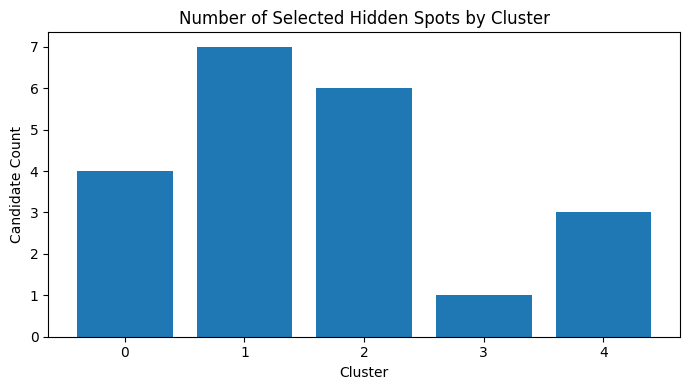

In [25]:
cluster_size = (
    cluster_plot_df
    .groupby("cluster")
    .size()
    .reset_index(name="candidate_count")
)

plt.figure(figsize=(7, 4))
plt.bar(cluster_size["cluster"].astype(str), cluster_size["candidate_count"])
plt.xlabel("Cluster")
plt.ylabel("Candidate Count")
plt.title("Number of Selected Hidden Spots by Cluster")
plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_k5_candidate_count.png", dpi=300)
plt.show()

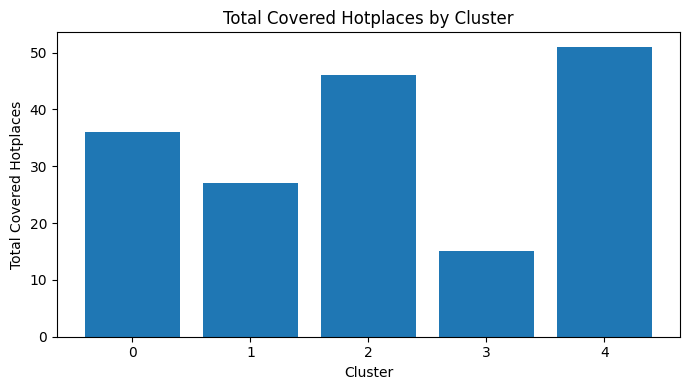

In [26]:
cluster_covered = (
    cluster_plot_df
    .groupby("cluster")["covered_h_count"]
    .sum()
    .reset_index(name="total_covered_h")
)

plt.figure(figsize=(7, 4))
plt.bar(cluster_covered["cluster"].astype(str), cluster_covered["total_covered_h"])
plt.xlabel("Cluster")
plt.ylabel("Total Covered Hotplaces")
plt.title("Total Covered Hotplaces by Cluster")
plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_k5_total_covered_h.png", dpi=300)
plt.show()

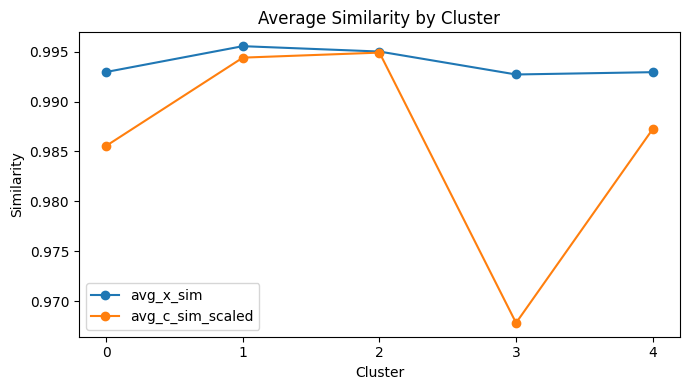

In [27]:
cluster_quality = (
    cluster_plot_df
    .groupby("cluster")
    .agg(
        avg_x_sim=("avg_x_sim", "mean"),
        avg_c_sim_scaled=("avg_c_sim_scaled", "mean"),
        avg_local_dist_m=("nearest_local_dist_m", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.plot(cluster_quality["cluster"].astype(str), cluster_quality["avg_x_sim"], marker="o", label="avg_x_sim")
plt.plot(cluster_quality["cluster"].astype(str), cluster_quality["avg_c_sim_scaled"], marker="o", label="avg_c_sim_scaled")
plt.xlabel("Cluster")
plt.ylabel("Similarity")
plt.title("Average Similarity by Cluster")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_k5_similarity.png", dpi=300)
plt.show()

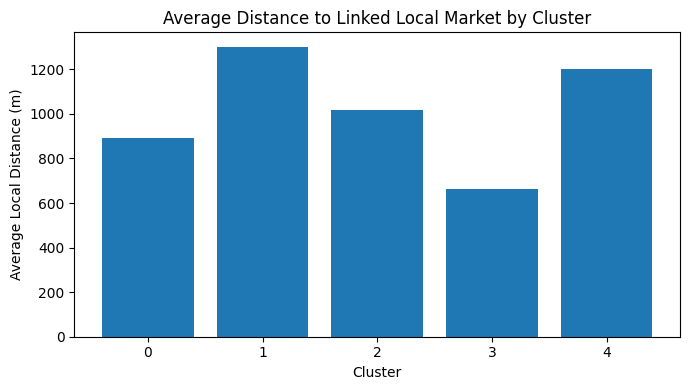

In [28]:
plt.figure(figsize=(7, 4))
plt.bar(cluster_quality["cluster"].astype(str), cluster_quality["avg_local_dist_m"])
plt.xlabel("Cluster")
plt.ylabel("Average Local Distance (m)")
plt.title("Average Distance to Linked Local Market by Cluster")
plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_k5_avg_local_distance.png", dpi=300)
plt.show()

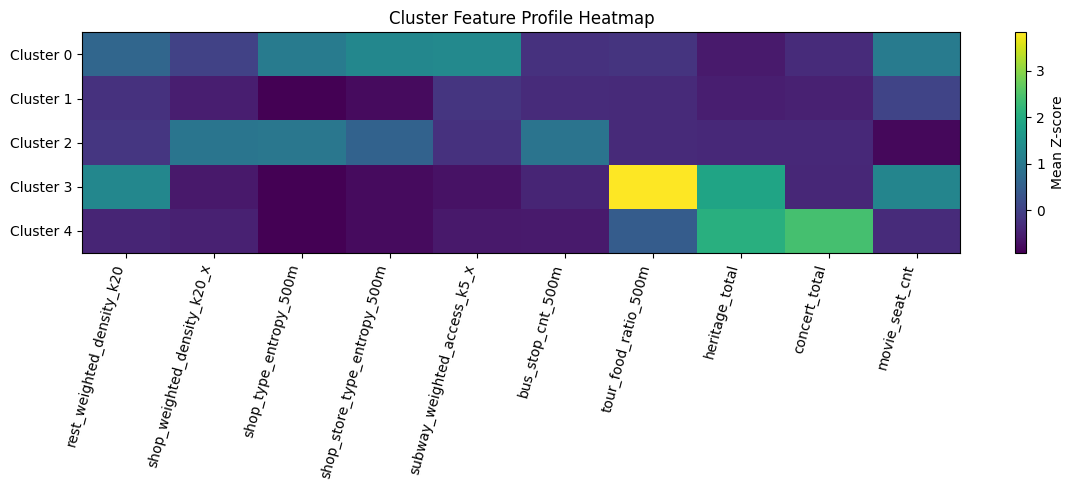

In [29]:
cluster_z_for_plot = cluster_z_summary.copy()

plt.figure(figsize=(12, 5))
plt.imshow(cluster_z_for_plot.values, aspect="auto")
plt.colorbar(label="Mean Z-score")
plt.xticks(
    ticks=np.arange(len(cluster_z_for_plot.columns)),
    labels=cluster_z_for_plot.columns,
    rotation=75,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(cluster_z_for_plot.index)),
    labels=[f"Cluster {i}" for i in cluster_z_for_plot.index]
)
plt.title("Cluster Feature Profile Heatmap")
plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_k5_feature_heatmap.png", dpi=300)
plt.show()

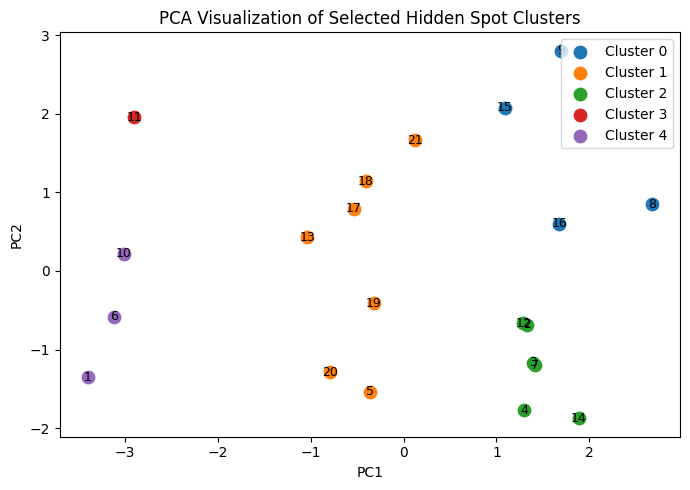

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

pca_plot_df = cluster_plot_df.copy()
pca_plot_df["PC1"] = X_pca_2d[:, 0]
pca_plot_df["PC2"] = X_pca_2d[:, 1]

plt.figure(figsize=(7, 5))

for cluster_id in sorted(pca_plot_df["cluster"].dropna().unique()):
    temp = pca_plot_df[pca_plot_df["cluster"] == cluster_id]
    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {cluster_id}",
        s=80
    )

for _, row in pca_plot_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        str(int(row["selection_order"])),
        fontsize=9,
        ha="center",
        va="center"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Selected Hidden Spot Clusters")
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_k5_pca_scatter.png", dpi=300)
plt.show()

In [ ]:
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

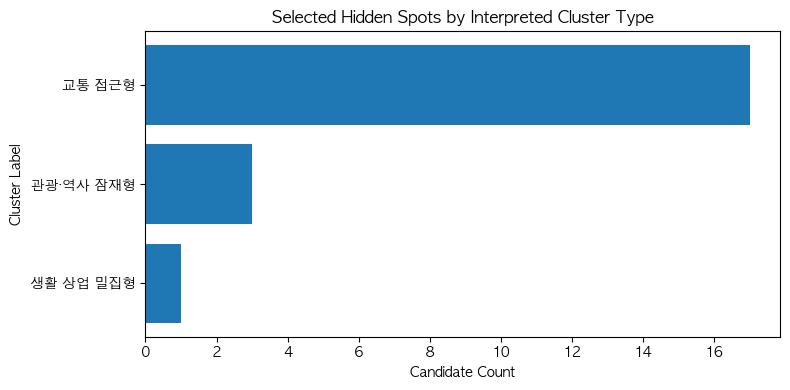

In [33]:
if "cluster_label" in cluster_plot_df.columns:
    label_count = (
        cluster_plot_df
        .groupby("cluster_label")
        .size()
        .reset_index(name="candidate_count")
        .sort_values("candidate_count", ascending=True)
    )

    plt.figure(figsize=(8, 4))
    plt.barh(label_count["cluster_label"], label_count["candidate_count"])
    plt.xlabel("Candidate Count")
    plt.ylabel("Cluster Label")
    plt.title("Selected Hidden Spots by Interpreted Cluster Type")
    plt.tight_layout()
    plt.savefig(RESULT_DIR / "cluster_k5_label_count.png", dpi=300)
    plt.show()

# Hidden Spot Cluster Analysis

최종 Facility Location optimization을 통해 선정된 21개의 hidden spot 후보에 대해 추가적인 도시 기능 해석을 수행하기 위해 exploratory clustering을 적용하였다.

본 단계의 목적은 엄밀한 통계적 군집 발견이 아니라,

```text
최종 후보들이 어떤 도시 기능 구조를 가지는지 해석
````

하기 위한 exploratory interpretation에 있다.

---

# 1. Cluster 수 결정

## 사용 feature

군집화에는 다음과 같은 도시 기능 feature를 사용하였다.

* 상업 밀도
* 상권 다양성
* 교통 접근성
* 관광 관련 feature
* 문화/공연 feature
* heritage 관련 feature

## 사용 변수

| 변수                             | 의미            |
| ------------------------------ | ------------- |
| `rest_weighted_density_k20`    | 음식점 밀도        |
| `shop_weighted_density_k20_x`  | 상업 밀도         |
| `shop_type_entropy_500m`       | 상권 다양성        |
| `shop_store_type_entropy_500m` | 점포 유형 다양성     |
| `subway_weighted_access_k5_x`  | 지하철 접근성       |
| `bus_stop_cnt_500m`            | 버스 접근성        |
| `tour_food_ratio_500m`         | 관광 소비 비율      |
| `heritage_total`               | heritage 자원   |
| `concert_total`                | 공연 관련 feature |
| `movie_seat_cnt`               | 영화관 규모        |

---

# 2. K 결정 결과

## Elbow Method

Elbow method 결과 inertia 감소 폭은 k=5 이후부터 점차 완화되는 경향을 보였다.

## Silhouette Score

Silhouette score 역시 k=5 이후 안정적으로 유지되었다.

---

# 최종 K 선택

| 이유         | 설명                       |
| ---------- | ------------------------ |
| sample 수   | 21개라 너무 많은 cluster 위험    |
| elbow      | k=5 근처부터 inertia 감소 폭 완화 |
| silhouette | k=5 이후 안정화               |
| 해석 가능성     | 도시 기능 유형 naming 가능       |

따라서 본 연구에서는 해석 가능성과 과도한 세분화를 동시에 고려하여 최종 cluster 수를 k=5로 설정하였다.

---

# 3. Cluster 규모 분석

| cluster | candidate_count | total_covered_h |
| ------- | --------------- | --------------- |
| 0       | 4               | 36              |
| 1       | 7               | 27              |
| 2       | 6               | 46              |
| 3       | 1               | 15              |
| 4       | 3               | 51              |

## 해석

Cluster 4는 후보 수는 적지만 가장 많은 hotplace coverage를 보였다.

즉 일부 후보는 매우 높은 대표성을 가지며 여러 혼잡 패턴을 동시에 설명할 수 있음을 의미한다.

반면 Cluster 1은 후보 수는 가장 많지만 개별 coverage는 상대적으로 작았다.

이는 비교적 세분화된 생활형 hidden spot들이 다수 존재함을 시사한다.

---

# 4. Similarity 분석

모든 cluster에서 평균 similarity는 매우 높게 유지되었다.

| cluster | avg_x_sim | avg_c_sim_scaled |
| ------- | --------- | ---------------- |
| 0       | 0.993     | 0.986            |
| 1       | 0.996     | 0.994            |
| 2       | 0.995     | 0.995            |
| 3       | 0.993     | 0.968            |
| 4       | 0.993     | 0.987            |

## 해석

모든 cluster에서:

* 도시 기능 유사성
* 소비 행동 유사성

이 모두 매우 높게 유지되었다.

즉 cluster가 달라지더라도 hidden spot 자체의 구조적 유사성은 유지된다는 점을 확인할 수 있었다.

이는 clustering이 similarity validity를 훼손하지 않는 범위 내에서 수행되었음을 의미한다.

---

# 5. Cluster Feature 해석

# Cluster 0 — 교통 접근형

## 주요 특징

| feature            | 특징    |
| ------------------ | ----- |
| subway access      | 매우 높음 |
| shop/store entropy | 높음    |
| movie seat         | 높음    |

## 대표 상권

* 마곡 미술길
* 건대입구 청춘대로
* 케미스트릿강남역

## 해석

Cluster 0은 교통 접근성과 상권 다양성이 높은 유형이다.

특히 지하철 접근성과 상업 entropy가 높게 나타났으며, 영화관 규모 역시 상대적으로 높은 편이었다.

즉:

```text
대중교통 접근성이 우수하고
복합 상업 기능이 활성화된 hidden spot 유형
```

으로 해석할 수 있다.

---

# Cluster 1 — 생활 상업형

## 주요 특징

| feature  | 특징    |
| -------- | ----- |
| density  | 중간 수준 |
| entropy  | 낮음    |
| heritage | 낮음    |

## 대표 상권

* 수유
* 천호자전거거리
* 상봉먹자골목

## 해석

Cluster 1은 전반적으로 관광 및 문화 요소는 낮지만 생활형 상업 기능이 안정적으로 존재하는 유형이다.

대규모 관광 집중보다는 지역 기반 소비 구조에 가까운 특징을 가진다.

즉:

```text
지역 생활 소비 기반의 생활형 hidden spot
```

으로 해석할 수 있다.

---

# Cluster 2 — 복합 상권 다양성형

## 주요 특징

| feature    | 특징    |
| ---------- | ----- |
| 상권 entropy | 매우 높음 |
| 버스 접근성     | 높음    |
| 상업 다양성     | 높음    |

## 대표 상권

* 광희동 중앙아시아거리
* 노량진 만나로
* 경춘선공릉숲길

## 해석

Cluster 2는 상권 다양성과 교통 접근성이 동시에 높은 유형이다.

특히 상업 entropy와 버스 접근성이 높게 나타났다.

이는 특정 기능에 집중된 공간이라기보다 다양한 소비 활동이 혼합된 구조임을 의미한다.

즉:

```text
복합 소비 활동이 혼재된 다기능형 hidden spot
```

으로 해석할 수 있다.

---

# Cluster 3 — 생활 상업 밀집형

## 주요 특징

| feature       | 특징    |
| ------------- | ----- |
| 음식점 밀도        | 매우 높음 |
| 관광 food ratio | 매우 높음 |
| heritage      | 높음    |

## 대표 상권

* 이태원

## 해석

Cluster 3은 음식점 밀도와 관광 관련 소비 비율이 매우 높은 특징을 보였다.

또한 heritage feature 역시 높게 나타났다.

즉:

```text
관광 소비와 상업 기능이 강하게 결합된 고밀도 소비형 hidden spot
```

으로 해석할 수 있다.

본 cluster는 단일 후보만 포함되었지만, 매우 강한 독립적 특성을 보였다.

---

# Cluster 4 — 관광·역사 잠재형

## 주요 특징

| feature        | 특징    |
| -------------- | ----- |
| concert_total  | 매우 높음 |
| heritage_total | 매우 높음 |
| tourism ratio  | 높음    |

## 대표 상권

* 서촌
* 광희동 중앙아시아거리

## 해석

Cluster 4는 공연·heritage·관광 관련 feature가 가장 높게 나타난 유형이다.

즉:

```text
문화·관광 잠재력이 높은 역사 기반 hidden spot
```

으로 해석할 수 있다.

특히 candidate 수는 적지만 total coverage는 가장 높게 나타났다.

이는 관광·역사 기반 hidden spot이 서울 전체 혼잡 패턴에 대해 높은 대표성을 가질 가능성을 시사한다.

---

# 6. PCA Visualization 해석

PCA 기반 2차원 시각화 결과 대부분의 cluster는 feature space 상에서 비교적 분리된 구조를 보였다.

특히:

* Cluster 3
* Cluster 4

는 다른 cluster와 명확히 분리되는 경향을 나타냈다.

이는 관광·문화 기반 hidden spot이 일반 생활형 hidden spot과 구조적으로 다른 특성을 가진다는 점을 시사한다.

---

# 7. 최종 해석

본 분석 결과 hidden spot은 단일 유형이 아니라,

* 교통 접근형
* 생활 상업형
* 복합 상권 다양성형
* 관광 소비형
* 관광·역사 잠재형

등 다양한 도시 기능 구조를 가진 집합으로 구성됨을 확인하였다.

즉 hidden spot은 단순히 “덜 알려진 장소”가 아니라,

```text
혼잡 지역과 기능적으로 유사하지만
아직 특정 집중 메커니즘이 과도하게 활성화되지 않은
잠재적 대체 목적지
```

로 해석할 수 있다.

이는 hidden spot 추천이 단순 관광 추천이 아니라,

```text
도시 혼잡 완화를 위한 수요 재분산 가능성 탐색
```

이라는 관점에서 의미를 가진다는 점을 시사한다.

```
```
